# 🎯 Système Intelligent Multi-Modèles pour la Rétention Client

> **Projet M1 Data Science** - Expert en Ingénierie de Données (RNCP40875 - Bloc 2)

Plateforme intelligente de prédiction du churn client et d'évaluation du risque de revenus pour entreprises SaaS, télécom et services par abonnement.

## Partie 1 : Analyse Exploratoire des Données (EDA)

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
BASE_PATH = Path.cwd().parent
DATA_PATH = BASE_PATH / "data"

CSV_PATH = DATA_PATH / "customer_churn_business_dataset.csv"

In [4]:
df = pd.read_csv(CSV_PATH)

df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

In [6]:
len(df)

10000

In [15]:
variables_numeriques = []
variables_categorielles = []
for col in df.columns:
    type = df[col].dtype
    if str(type).startswith("int") or str(type).startswith("float"):
        variables_numeriques.append(col)
    else:
        variables_categorielles.append(col)

print("Variables numériques :", variables_numeriques)

Variables numériques : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'churn']


Le dataset **Customer Churn Business** contient **10 000 observations** (clients) et **31 colonnes** représentant différentes caractéristiques comportementales, démographiques et transactionnelles.

**Colonnes du Dataset** :

- `customer_id` : Identifiant unique du client
- `gender` : Genre du client (Male, Female)
- `country` : Pays du client
- `city` : Ville du client
- `customer_segment` : Segment de clientèle
- `tenure_months`: Ancienneté du client (mois)
- `signup_channel`: Méthode de connection (Web, Mobile, ...)
- `contract_type`: Type de contrat (Monthly, Annual, Two-Year)
- `monthly_logins`: Nombre de connexions mensuelles
- `weekly_active_days`: Nombre de jours actifs par semaine
- `avg_session_time`: Temps moyen de session
- `features_used`: Nombre de fonctionnalités utilisées
- `usage_growth_rate`: Taux de croissance de l'utilisation
- `last_login_days_ago`: Nombre de jours depuis la dernière connexion
- `monthly_fee`: Frais mensuels payés par le client ($)
- `total_revenue`: Revenu total généré par le client ($)
- `payment_method`: Méthode de paiement utilisée
- `payment_failures`: Nombre d'échecs de paiement
- `discount_applied`: Montant total des réductions appliquées ($)
- `price_increase_last_3m`: Indique si une augmentation de prix récente a eu lieu (true / false).
- `support_tickets`: Nombre de tickets support ouverts
- `avg_resolution_time`: Temps moyen de résolution des tickets (heures)
- `complaint_type`: Type de plainte au service client
- `csat_score`: Score de satisfaction client
- `escalations`: Nombre d'escalades service client
- `email_open_rate`: Taux d'ouverture des emails marketing (%)
- `marketing_click_rate`: Taux de clics sur les campagnes marketing (%)
- `nps_score`: Net Promoter Score (0-100) - indicateur de satisfaction
- `survey_response`: Taux de réponse aux enquêtes (%)
- `referral_count`: Nombre de parrainages effectués
- `churn`: Indicateur de résiliation (0 = Non, 1 = Oui) ← **Variable à prédire**

**Objectif** : Prédire la probabilité qu'un client résilie son abonnement (`churn = 1`) en se basant sur ces 30 features.


### Distribution de la variable cible `churn`

In [8]:
churn_counts = df['churn'].value_counts()
churn_percentages = df['churn'].value_counts(normalize=True) * 100

In [9]:
print("📊 DISTRIBUTION DE LA VARIABLE CIBLE : CHURN")
print()
print(f"\nNombre de clients par classe:")
print(f"  • Churn = 0 (Clients fidèles)  : {churn_counts[0]:,} ({churn_percentages[0]:.2f}%)")
print(f"  • Churn = 1 (Clients partis)   : {churn_counts[1]:,} ({churn_percentages[1]:.2f}%)")
print(f"\nTotal clients : {len(df):,}")
print(f"Taux de churn global : {churn_percentages[1]:.2f}%")

📊 DISTRIBUTION DE LA VARIABLE CIBLE : CHURN


Nombre de clients par classe:
  • Churn = 0 (Clients fidèles)  : 8,979 (89.79%)
  • Churn = 1 (Clients partis)   : 1,021 (10.21%)

Total clients : 10,000
Taux de churn global : 10.21%


In [10]:
# Calcul du revenu à risque
revenue_at_risk = df[df['churn'] == 1]['total_revenue'].sum()
total_revenue = df['total_revenue'].sum()
revenue_risk_pct = (revenue_at_risk / total_revenue) * 100

In [11]:
print(f"IMPACT BUSINESS:")
print(f"  • Revenu total généré      : ${total_revenue:,.2f}")
print(f"  • Revenu à risque (churners): ${revenue_at_risk:,.2f}")
print(f"  • Pourcentage à risque     : {revenue_risk_pct:.2f}%")

IMPACT BUSINESS:
  • Revenu total généré      : $10,570,180.00
  • Revenu à risque (churners): $862,640.00
  • Pourcentage à risque     : 8.16%


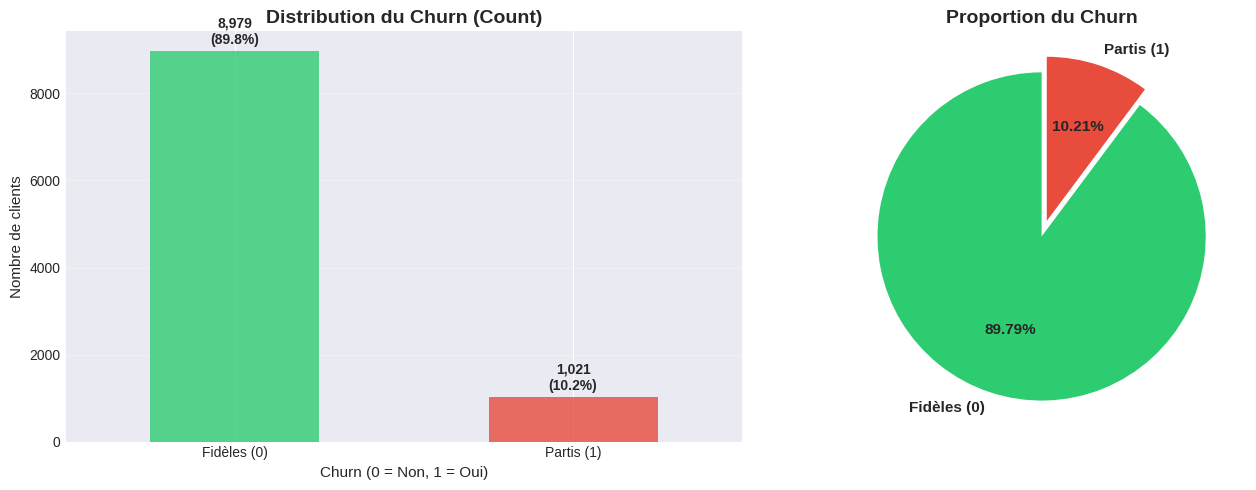

In [12]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Barplot
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_title('Distribution du Churn (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0 = Non, 1 = Oui)', fontsize=11)
axes[0].set_ylabel('Nombre de clients', fontsize=11)
axes[0].set_xticklabels(['Fidèles (0)', 'Partis (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 100, f'{v:,}\n({churn_percentages.iloc[i]:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# Graphique 2 : Pie chart
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)  # Explode le segment churn=1
axes[1].pie(churn_counts, labels=['Fidèles (0)', 'Partis (1)'], autopct='%1.2f%%',
           colors=colors, explode=explode, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Proportion du Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# Vérification du déséquilibre des classes
ratio = churn_counts[0] / churn_counts[1]
print(f"⚖️ DÉSÉQUILIBRE DES CLASSES:")
print(f"  Ratio (Fidèles / Partis) : {ratio:.2f}:1")

⚖️ DÉSÉQUILIBRE DES CLASSES:
  Ratio (Fidèles / Partis) : 8.79:1


Conclusion partielle : **le déséquilibre des classes est fort**, environ 90% / 10%. La majorité des clients sont fidèles (churn = 0), tandis qu'une minorité résilie (churn = 1). Ce déséquilibre devra être pris en compte lors de la modélisation pour éviter un biais vers la classe majoritaire. Il faudra envisager les points suivants :
- `class_weight='balanced'` dans TOUS les modèles
- Métriques prioritaires: Recall, F1-Score, PR-AUC (ROC-AUC)
- Ne surtout pas utiliser Accuracy comme métrique principale
- Stratified split OBLIGATOIRE (stratify=y)

A étudier : SMOTE, sous-échantillonnage ou ajustement du seuil de décision

### Identification des variables

In [14]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valeurs uniques")

customer_id: 10000 valeurs uniques
gender: 2 valeurs uniques
age: 57 valeurs uniques
country: 7 valeurs uniques
city: 7 valeurs uniques
customer_segment: 3 valeurs uniques
tenure_months: 59 valeurs uniques
signup_channel: 3 valeurs uniques
contract_type: 3 valeurs uniques
monthly_logins: 53 valeurs uniques
weekly_active_days: 8 valeurs uniques
avg_session_time: 9777 valeurs uniques
features_used: 15 valeurs uniques
usage_growth_rate: 104 valeurs uniques
last_login_days_ago: 71 valeurs uniques
monthly_fee: 6 valeurs uniques
total_revenue: 221 valeurs uniques
payment_method: 3 valeurs uniques
payment_failures: 6 valeurs uniques
discount_applied: 2 valeurs uniques
price_increase_last_3m: 2 valeurs uniques
support_tickets: 8 valeurs uniques
avg_resolution_time: 9883 valeurs uniques
complaint_type: 3 valeurs uniques
csat_score: 5 valeurs uniques
escalations: 5 valeurs uniques
email_open_rate: 81 valeurs uniques
marketing_click_rate: 50 valeurs uniques
nps_score: 197 valeurs uniques
survey_r

In [16]:
variables_numeriques = [
    "age",
    "tenure_months",
    "monthly_logins",
    "weekly_active_days",
    "avg_session_time",
    "features_used",
    "usage_growth_rate",
    "last_login_days_ago",
    "monthly_fee",
    "total_revenue",
    "payment_failures",
    "support_tickets",
    "avg_resolution_time",
    "csat_score",
    "escalations",
    "email_open_rate",
    "marketing_click_rate",
    "nps_score",
    "referral_count",
]

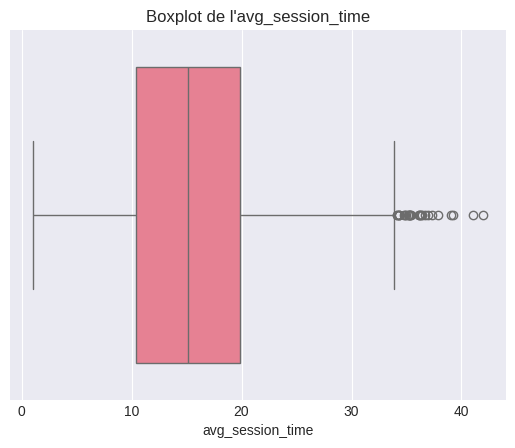

In [18]:
sns.boxplot(x=df["avg_session_time"])
plt.title("Boxplot de l'avg_session_time")
plt.show()